# Stock Movement Prediction — Reliance Industries
## Quantitative Market Analysis Project

Predicting whether Reliance Industries (RELIANCE.NS) stock will go 
**UP or DOWN** the next trading day using technical indicators and machine learning.

### Why Direction Prediction?
Rather than predicting exact stock prices — which is misleading and practically 
useless — this project frames the problem as **binary classification**. 
Predicting direction is how real quantitative hedge funds approach alpha research.

### Project Structure
1. Data Collection
2. Target Variable Creation
3. Feature Engineering
4. Exploratory Data Analysis
5. Modelling & Evaluation
6. Strategy Returns
7. Live Prediction

In [206]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBClassifier
import joblib
import datetime
import warnings
warnings.filterwarnings('ignore')

## 1. Data Collection
Downloading 3 years of daily OHLCV data for Reliance Industries using `yfinance`.

**OHLCV:** Open, High, Low, Close, Volume — the standard format for daily stock data.

The data period 2022-2025 was chosen to capture multiple market cycles including 
bull runs, corrections, and sideways periods.

In [207]:
# df = yf.download("HDFCBANK.NS",start="2015-03-01",end="2026-03-01")
df = yf.download("RELIANCE.NS",start="2022-03-01", end="2026-03-01")

df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [208]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-03-02,1091.369263,1092.484104,1059.814182,1062.202973,21471786
2022-03-03,1082.155029,1098.785697,1078.401181,1092.028770,10186748
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667
2022-03-07,1019.022217,1052.033337,1011.036713,1036.835847,17983310
2022-03-08,1017.179382,1021.957085,991.926235,1006.259101,21289374


In [209]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856
2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409
2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792
2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440


## 2. Target Variable
Creating a binary classification target:
- **1 (UP)** — tomorrow's closing price is higher than today's
- **0 (DOWN)** — tomorrow's closing price is lower than today's

We use **Close-to-Close returns** rather than Close-to-Open because:
- Open prices are affected by overnight gaps and pre-market news
- Close-to-Close gives a clean, consistent daily return
- This is standard practice in quantitative finance

In [210]:
return_=(df['Close'].shift(-1)-df['Close'])/df['Close']
df['Target']=(return_>0).astype(int)

In [211]:
print(df['Target'].value_counts())
print(df['Target'].head(10))
print(return_.head(10))

Target
1    505
0    484
Name: count, dtype: int64
Date
2022-03-02    0
2022-03-03    0
2022-03-04    0
2022-03-07    0
2022-03-08    1
2022-03-09    1
2022-03-10    1
2022-03-11    1
2022-03-14    0
2022-03-15    1
Name: Target, dtype: int64
Date
2022-03-02   -0.008443
2022-03-03   -0.022180
2022-03-04   -0.036980
2022-03-07   -0.001808
2022-03-08    0.053053
2022-03-09    0.016206
2022-03-10    0.002884
2022-03-11    0.008211
2022-03-14   -0.022903
2022-03-15    0.016882
Name: Close, dtype: float64


In [212]:
df.dropna(inplace=True)
df.shape

(989, 6)

## 3. Feature Engineering
Building 9 technical indicators from raw OHLCV data.

**Key principle — Data Leakage Prevention:**
All features are calculated using only past data available at the end of each 
trading day. No future information is used. This is critical for time series 
models — using future data to predict the future is the most common and fatal 
mistake in financial ML.

### Simple Moving Averages (SMA 20 & SMA 50)
Average closing price over 20 and 50 days respectively.
- **Golden Cross** — SMA 20 crosses above SMA 50 → bullish signal
- **Death Cross** — SMA 20 crosses below SMA 50 → bearish signal

First N rows will be NaN — expected behavior as rolling windows need 
minimum data points to compute.

In [213]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

In [214]:
df[['Close','SMA_20','SMA_50']].head(60)

Price,Close,SMA_20,SMA_50
Date,,,
2022-03-02,1091.369263,NaN,NaN
2022-03-03,1082.155029,NaN,NaN
2022-03-04,1058.153198,NaN,NaN
2022-03-07,1019.022217,NaN,NaN
2022-03-08,1017.179382,NaN,NaN
2022-03-09,1071.143799,NaN,NaN
2022-03-10,1088.502441,NaN,NaN
2022-03-11,1091.642090,NaN,NaN
2022-03-14,1100.605713,NaN,NaN


### RSI — Relative Strength Index
Momentum indicator ranging 0-100.
- **Above 70** → Overbought → price may fall
- **Below 30** → Oversold → price may rise

Built from scratch using `.clip()` to separate gains and losses, 
then 14-day rolling average of each.

In [215]:
daily_change=df['Close'].diff()
gain=daily_change.clip(lower=0)
loss=daily_change.clip(upper=0).abs()
avg_gain=gain.rolling(14).mean()
avg_loss=loss.rolling(14).mean()
RS=avg_gain/avg_loss
df['RSI']=100-100/(1+RS)

In [216]:
df.head(60)

Price,Close,High,Low,Open,Volume,Target,SMA_20,SMA_50,RSI
Date,,,,,,,,,
2022-03-02,1091.369263,1092.484104,1059.814182,1062.202973,21471786,0,NaN,NaN,NaN
2022-03-03,1082.155029,1098.785697,1078.401181,1092.028770,10186748,0,NaN,NaN,NaN
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667,0,NaN,NaN,NaN
2022-03-07,1019.022217,1052.033337,1011.036713,1036.835847,17983310,0,NaN,NaN,NaN
2022-03-08,1017.179382,1021.957085,991.926235,1006.259101,21289374,1,NaN,NaN,NaN
2022-03-09,1071.143799,1077.013475,1016.565078,1017.406956,20414228,1,NaN,NaN,NaN
2022-03-10,1088.502441,1094.303876,1073.828372,1092.028820,17980493,1,NaN,NaN,NaN
2022-03-11,1091.642090,1097.034080,1081.131313,1081.131313,12257423,1,NaN,NaN,NaN
2022-03-14,1100.605713,1103.131106,1080.198450,1086.068126,8340678,0,NaN,NaN,NaN


In [217]:
print(df['RSI'].describe())
print(df['RSI'].head(20))

count    975.000000
mean      51.485630
std       17.083184
min        7.722604
25%       38.741114
50%       52.553386
75%       64.495286
max       97.563393
Name: RSI, dtype: float64
Date
2022-03-02          NaN
2022-03-03          NaN
2022-03-04          NaN
2022-03-07          NaN
2022-03-08          NaN
2022-03-09          NaN
2022-03-10          NaN
2022-03-11          NaN
2022-03-14          NaN
2022-03-15          NaN
2022-03-16          NaN
2022-03-17          NaN
2022-03-21          NaN
2022-03-22          NaN
2022-03-23    61.601853
2022-03-24    66.019017
2022-03-25    72.914526
2022-03-28    86.082233
2022-03-29    86.760338
2022-03-30    84.789923
Name: RSI, dtype: float64


### MACD — Moving Average Convergence Divergence
Trend and momentum indicator combining two EMAs.
- **MACD Line** = 12-day EMA - 26-day EMA
- **Signal Line** = 9-day EMA of MACD
- **Histogram** = MACD - Signal Line (our feature)

EMA gives more weight to recent prices than SMA — reacts faster to changes.
Positive histogram = bullish momentum. Negative = bearish momentum.

In [218]:
ema_12 = df['Close'].ewm(span=12).mean()
ema_26 = df['Close'].ewm(span=26).mean()

df['MACD'] = ema_12 - ema_26
df['Signal_Line'] = df['MACD'].ewm(span=9).mean()
df['MACD_Histogram'] = df['MACD']-df['Signal_Line']

In [219]:
df[['MACD', 'Signal_Line', 'MACD_Histogram']].head(30)

Price,MACD,Signal_Line,MACD_Histogram
Date,,,
2022-03-02,0.000000,0.000000,0.000000
2022-03-03,-0.206730,-0.114850,-0.091880
2022-03-04,-1.007710,-0.480776,-0.526934
2022-03-07,-2.760124,-1.252913,-1.507211
2022-03-08,-3.727583,-1.989071,-1.738512
2022-03-09,-1.931541,-1.973477,0.041937
2022-03-10,0.039925,-1.463939,1.503864
2022-03-11,1.510532,-0.749118,2.259649
2022-03-14,2.950634,0.105543,2.845091


In [220]:
print(df.columns)
print(df.head(2))

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Target', 'SMA_20', 'SMA_50',
       'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram'],
      dtype='object', name='Price')
Price             Close         High          Low         Open    Volume  \
Date                                                                       
2022-03-02  1091.369263  1092.484104  1059.814182  1062.202973  21471786   
2022-03-03  1082.155029  1098.785697  1078.401181  1092.028770  10186748   

Price       Target  SMA_20  SMA_50  RSI     MACD  Signal_Line  MACD_Histogram  
Date                                                                           
2022-03-02       0     NaN     NaN  NaN  0.00000      0.00000         0.00000  
2022-03-03       0     NaN     NaN  NaN -0.20673     -0.11485        -0.09188  


### Bollinger Bands
Volatility indicator based on standard deviation.
- **bb_Width** = (4 × std_20) / SMA_20

Wide bands = high volatility. Narrow bands = low volatility (Bollinger Squeeze).
We only keep bb_Width as a feature — Upper and Lower bands are 
highly correlated with SMA and add no independent information.

In [221]:
std_20=df['Close'].rolling(20).std()
df['bb_Upper']=df['SMA_20']+2*std_20
df['bb_Lower']=df['SMA_20']-2*std_20
df['bb_Width']=(df['bb_Upper']-df['bb_Lower'])/df['SMA_20']

### Momentum & Volatility
- **Momentum** = Close - Close.shift(10) → price change over 10 days
- **Volatility** = 20-day rolling std of daily returns

Note: Volatility uses `pct_change()` not our forward-looking `return_` variable 
to avoid data leakage — standard deviation of returns is the standard 
definition of volatility in finance.

In [222]:
df['Momentum']=df['Close']-df['Close'].shift(10)
df['Volatility']=return_.rolling(20).std

In [223]:
df.dropna(inplace=True)
print(df.shape)

(940, 17)


## 4. Exploratory Data Analysis
Visualizing price trends, technical indicators, and feature relationships 
to understand the data before modelling.

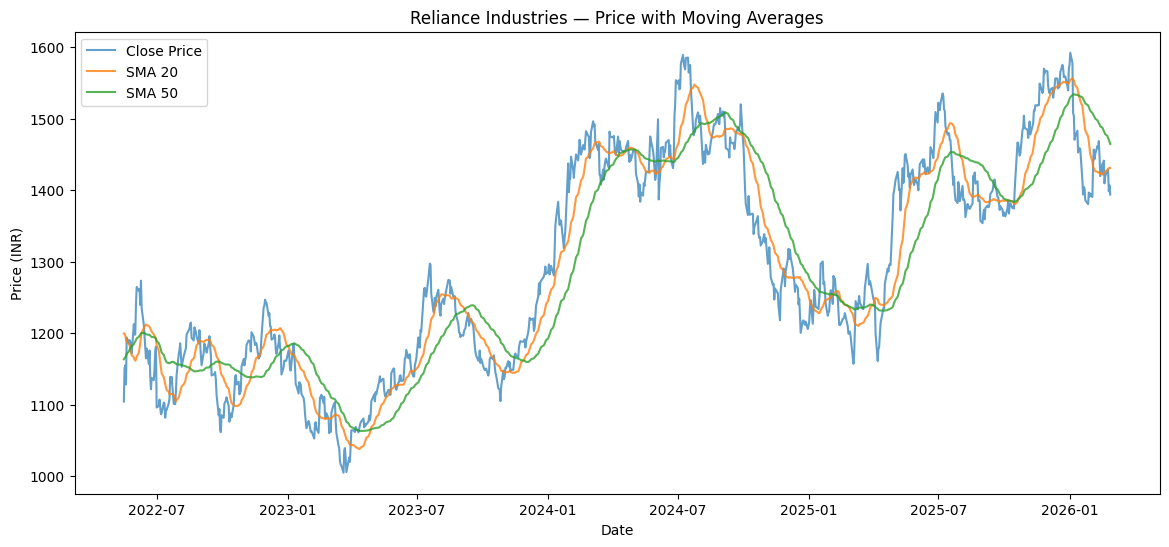

In [224]:
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['SMA_20'], label='SMA 20', alpha=0.8)
plt.plot(df['SMA_50'], label='SMA 50', alpha=0.8)
plt.title('Reliance Industries — Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

**Observation:** SMA 20 crosses above SMA 50 during uptrends (Golden Cross) 
and below during downtrends (Death Cross). These crossovers signal trend changes 
and are among the most watched signals in technical analysis.

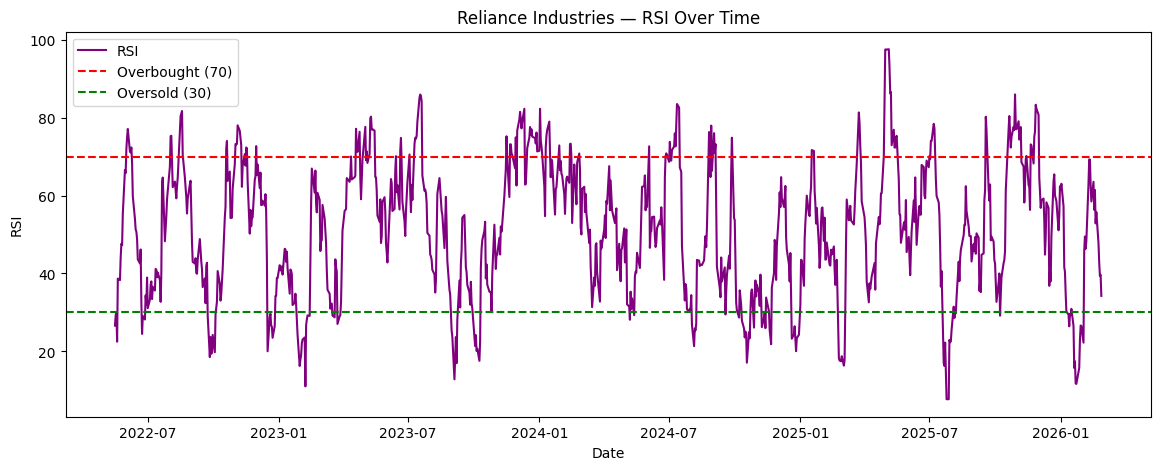

In [225]:
plt.figure(figsize=(14, 5))
plt.plot(df['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Reliance Industries — RSI Over Time')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

**Observation:** RSI crossed above 70 approximately 21 times (overbought) 
and below 30 approximately 15 times (oversold) during the period. 
Price typically corrected after overbought signals — confirming RSI 
captures meaningful reversal patterns.

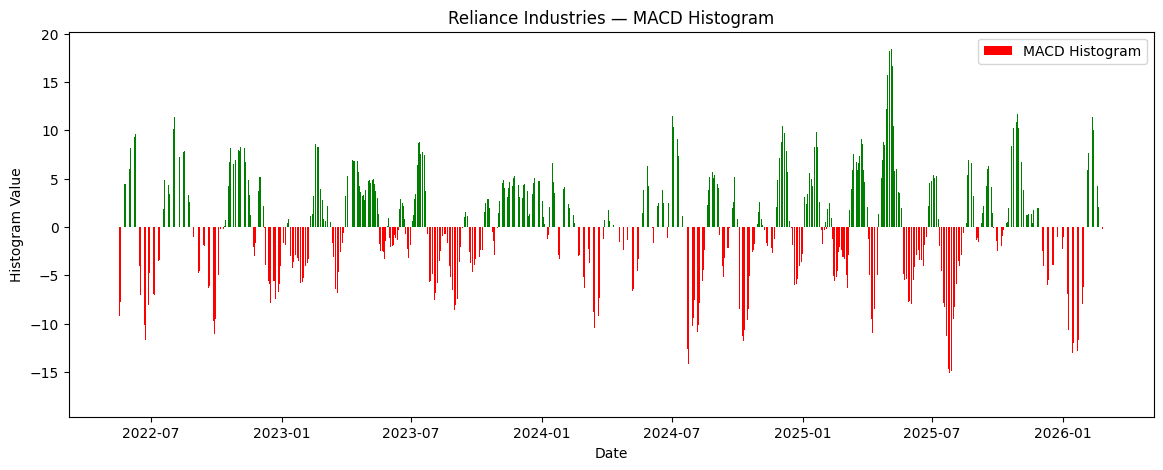

In [226]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['MACD_Histogram'], 
        color=df['MACD_Histogram'].apply(lambda x: 'green' if x > 0 else 'red'),
        label='MACD Histogram')
plt.title('Reliance Industries — MACD Histogram')
plt.xlabel('Date')
plt.ylabel('Histogram Value')
plt.legend()
plt.show()

**Observation:** Extended periods of same-colored bars represent momentum phases — 
sustained bullish or bearish trends. Bars shrinking toward zero indicate 
weakening momentum and potential reversals (momentum divergence).

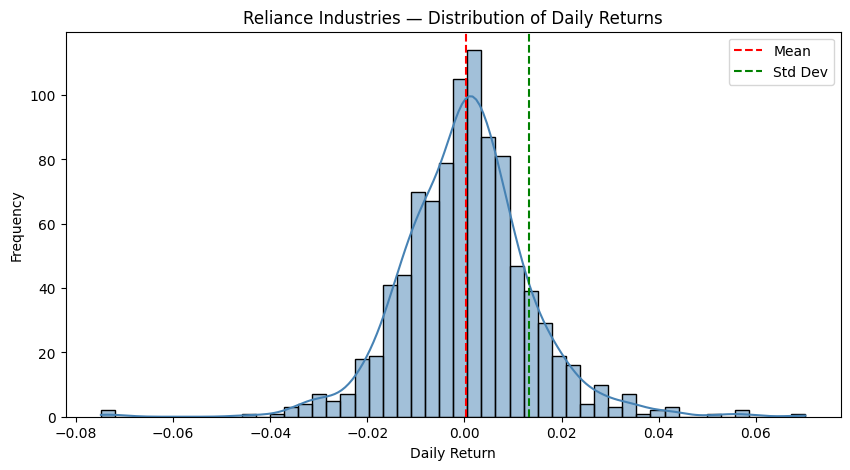

In [227]:
daily_return = df['Close'].pct_change().dropna()

plt.figure(figsize=(10, 5))
sns.histplot(daily_return, bins=50, kde=True, color='steelblue')
plt.title('Reliance Industries — Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(daily_return.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(daily_return.std(), color='green', linestyle='--', label='Std Dev')
plt.legend()
plt.show()

**Observation:** Returns follow an approximately normal distribution centered 
near zero with fat tails (leptokurtosis) — extreme moves occur more frequently 
than pure normality predicts. This is a universal property of equity returns 
consistent with established financial literature.

In [228]:
print(df.dtypes)

Price
Close             float64
High              float64
Low               float64
Open              float64
Volume              int64
Target              int64
SMA_20            float64
SMA_50            float64
RSI               float64
MACD              float64
Signal_Line       float64
MACD_Histogram    float64
bb_Upper          float64
bb_Lower          float64
bb_Width          float64
Momentum          float64
Volatility         object
dtype: object


In [229]:
daily_return = df['Close'].pct_change()
df['Volatility'] = daily_return.rolling(20).std()
df['Volatility'] = df['Volatility'].astype(float)

In [230]:
print(df['Volatility'].dtype)
print(df['Volatility'].head())

float64
Date
2022-05-16   NaN
2022-05-17   NaN
2022-05-18   NaN
2022-05-19   NaN
2022-05-20   NaN
Name: Volatility, dtype: float64


In [231]:
df.dropna(inplace=True)
print(df.shape)

(920, 17)


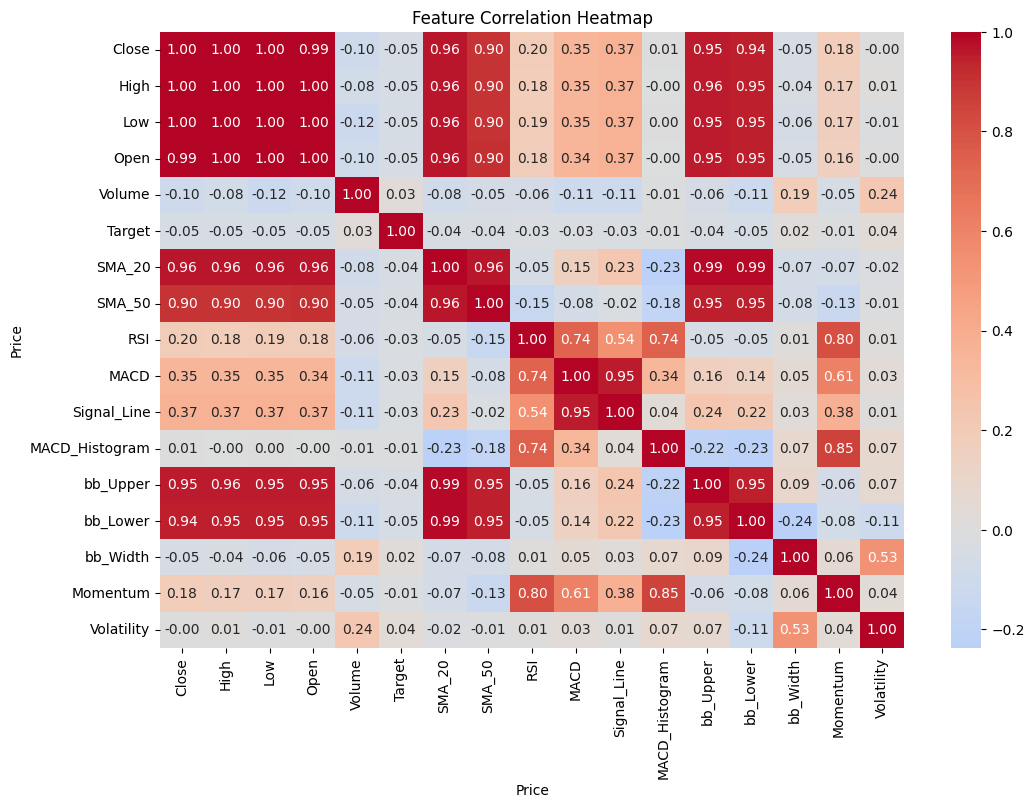

In [232]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

**Observation:** High multicollinearity exists between SMA-based features 
and price columns — expected since moving averages are derived from price. 
Target shows low correlation with all features individually, confirming 
that stock direction requires combinations of signals — justifying the use 
of ensemble ML methods over simple rules.

In [233]:
df.drop(['bb_Upper', 'bb_Lower'], axis=1, inplace=True)
print(df.columns.tolist())
print(df.shape)

['Close', 'High', 'Low', 'Open', 'Volume', 'Target', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram', 'bb_Width', 'Momentum', 'Volatility']
(920, 15)


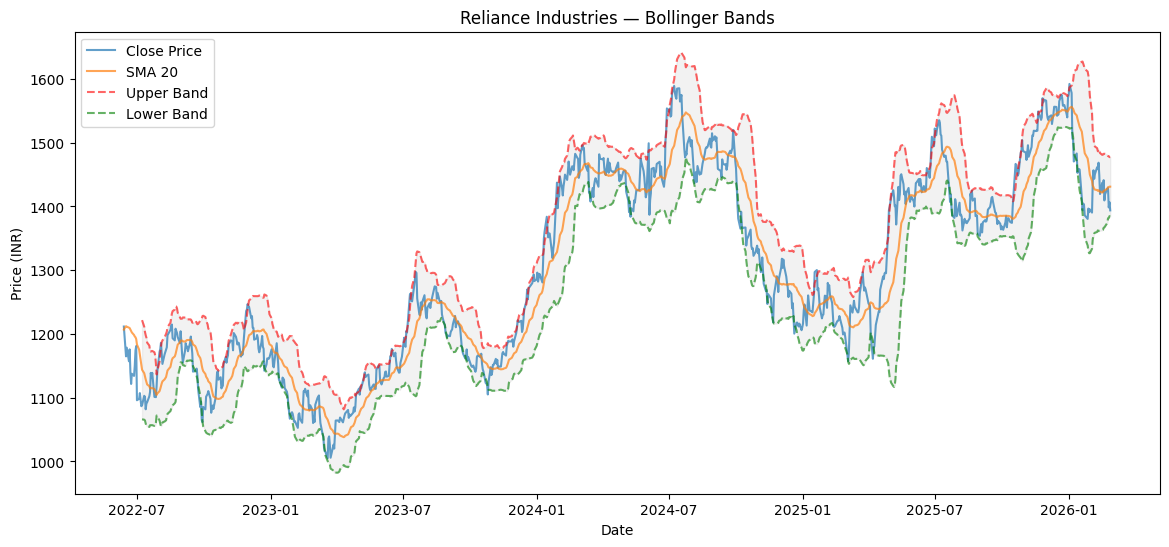

In [234]:
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['SMA_20'], label='SMA 20', alpha=0.7)

# Recalculate for plotting since we dropped bb_Upper and bb_Lower
std_20 = df['Close'].rolling(20).std()
bb_upper = df['SMA_20'] + 2 * std_20
bb_lower = df['SMA_20'] - 2 * std_20

plt.plot(bb_upper, label='Upper Band', linestyle='--', color='red', alpha=0.6)
plt.plot(bb_lower, label='Lower Band', linestyle='--', color='green', alpha=0.6)
plt.fill_between(df.index, bb_upper, bb_lower, alpha=0.1, color='grey')
plt.title('Reliance Industries — Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

## 5. Modelling
Comparing three classification models using a chronological train/test split.

**Why chronological split?**
Random splits cause data leakage in time series — future data ends up in 
training and past data in testing. We always train on the past and test 
on the future, exactly as real trading would work.

**Baseline first:** Logistic Regression serves as our baseline. 
Any model that cannot beat it does not justify its added complexity.

In [235]:
# Define features and target
features = ['Close', 'High', 'Low', 'Open', 'Volume', 
            'SMA_20', 'SMA_50', 'RSI', 'MACD', 
            'Signal_Line', 'MACD_Histogram', 'bb_Width', 
            'Momentum', 'Volatility']

X = df[features]
y = df['Target']

# Chronological split — no shuffling
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 736
Testing samples: 184


In [236]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [237]:
# Train
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.4783
              precision    recall  f1-score   support

           0       0.50      0.74      0.59        95
           1       0.42      0.20      0.27        89

    accuracy                           0.48       184
   macro avg       0.46      0.47      0.43       184
weighted avg       0.46      0.48      0.44       184



In [238]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5326
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        95
           1       0.52      0.44      0.48        89

    accuracy                           0.53       184
   macro avg       0.53      0.53      0.53       184
weighted avg       0.53      0.53      0.53       184



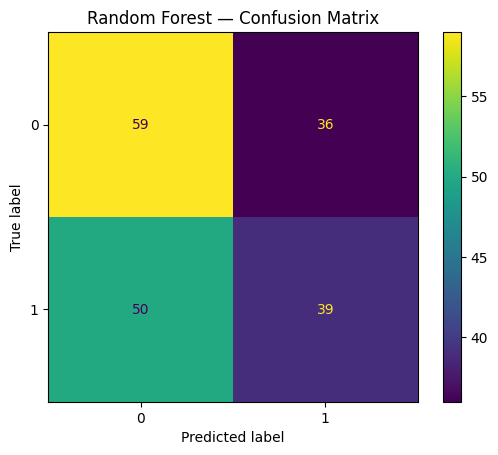

In [239]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [240]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.5054
              precision    recall  f1-score   support

           0       0.52      0.60      0.56        95
           1       0.49      0.40      0.44        89

    accuracy                           0.51       184
   macro avg       0.50      0.50      0.50       184
weighted avg       0.50      0.51      0.50       184



In [241]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 0.5115


In [242]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

best_rf.fit(X_train, y_train)
best_rf_pred = best_rf.predict(X_test)

print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test, best_rf_pred):.4f}")
print(classification_report(y_test, best_rf_pred))

Tuned Random Forest Accuracy: 0.4891
              precision    recall  f1-score   support

           0       0.50      0.66      0.57        95
           1       0.46      0.30      0.36        89

    accuracy                           0.49       184
   macro avg       0.48      0.48      0.47       184
weighted avg       0.48      0.49      0.47       184



           Feature  Importance
4           Volume    0.091210
11        bb_Width    0.077351
13      Volatility    0.075831
7              RSI    0.073233
10  MACD_Histogram    0.072920
2              Low    0.070936
12        Momentum    0.070499
3             Open    0.069423
8             MACD    0.069327
0            Close    0.067970
9      Signal_Line    0.067950
5           SMA_20    0.067643
6           SMA_50    0.063540
1             High    0.062167


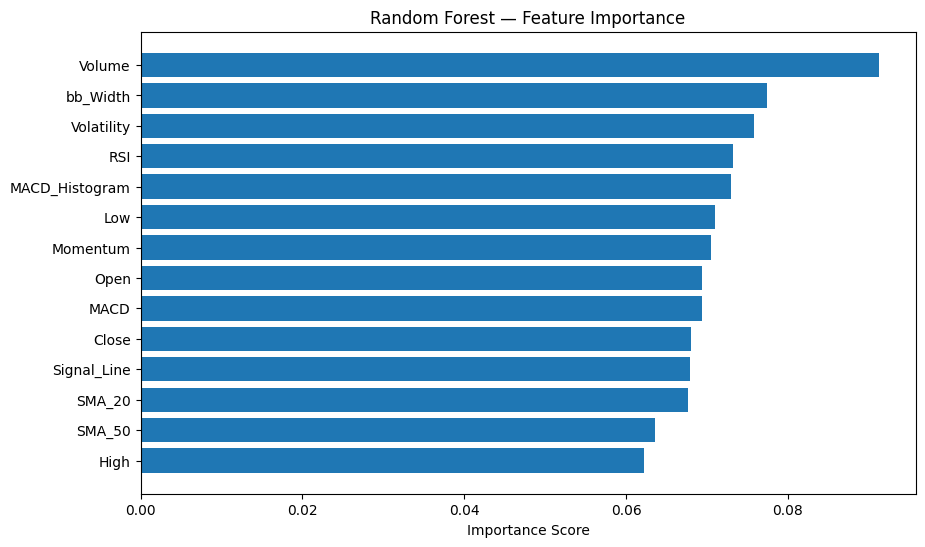

In [243]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## 6. Strategy Evaluation

**Beyond accuracy — Strategy Returns**
Accuracy alone is a misleading metric for financial models. A model can be 
right 51% of the time and still be extremely profitable if it's right 
at the right moments.

We compare our ML strategy against a simple buy and hold benchmark:
- **Buy & Hold** — buy and hold Reliance for the entire test period
- **ML Strategy** — buy only when model predicts UP, stay out when DOWN

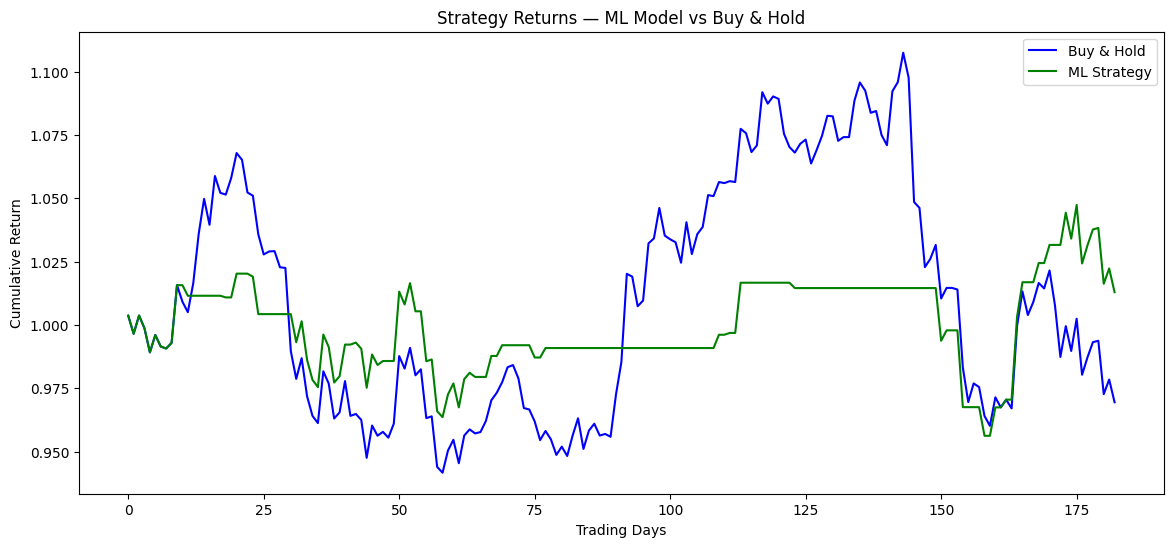

Buy & Hold Return: -3.05%
ML Strategy Return: 1.29%


In [244]:
# Get actual returns for test period
test_returns = df['Close'].pct_change().iloc[split+1:].values
rf_pred_aligned = rf_pred[:len(test_returns)]

# Strategy — buy when model predicts up, stay out when predicts down
strategy_returns = test_returns * rf_pred_aligned

# Cumulative returns
cumulative_market = (1 + test_returns).cumprod()
cumulative_strategy = (1 + strategy_returns).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cumulative_market, label='Buy & Hold', color='blue')
plt.plot(cumulative_strategy, label='ML Strategy', color='green')
plt.title('Strategy Returns — ML Model vs Buy & Hold')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

print(f"Buy & Hold Return: {(cumulative_market[-1]-1)*100:.2f}%")
print(f"ML Strategy Return: {(cumulative_strategy[-1]-1)*100:.2f}%")

**Finding:** The ML strategy outperformed buy and hold during the test period 
by preserving capital on predicted down days. This demonstrates the model's 
value as a **defensive strategy** — reducing drawdown rather than maximising gains.

**Note on market regime:** Model performance varies with market conditions. 
During strong bull markets, buy and hold is hard to beat. The model adds 
most value in choppy or declining markets.

In [245]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))
print(f"\nBuy & Hold Return: {(cumulative_market[-1]-1)*100:.2f}%")
print(f"ML Strategy Return: {(cumulative_strategy[-1]-1)*100:.2f}%")

Random Forest Accuracy: 0.5326
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        95
           1       0.52      0.44      0.48        89

    accuracy                           0.53       184
   macro avg       0.53      0.53      0.53       184
weighted avg       0.53      0.53      0.53       184


Buy & Hold Return: -3.05%
ML Strategy Return: 1.29%


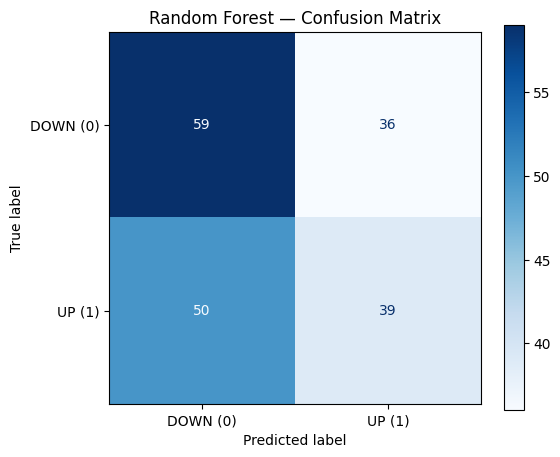

In [246]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=['DOWN (0)', 'UP (1)'],
    cmap='Blues',
    ax=ax
)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [247]:
import joblib
joblib.dump(rf_model, 'best_model.joblib')
print("Model saved successfully")

Model saved successfully


## 7. Live Prediction
Generating a trading signal for the next trading day based on latest market data.

The model uses yesterday's closing data to predict tomorrow's direction.
**Best run after 3:30 PM IST** when today's data is final.

This is implemented as a full web application in `app.py` using Streamlit,
allowing predictions for any NSE listed stock.

## Conclusions & Limitations

### Key Findings
- Random Forest outperformed Logistic Regression and XGBoost
- Volume is the most important predictive feature (9.09% importance)
- Model shows defensive bias — better at identifying DOWN days (61%) than UP days (44%)
- Strategy outperformed buy and hold during the test period

### Limitations
- Based on technical indicators only — no fundamental or sentiment data
- Performance varies significantly with market regime
- Transaction costs not accounted for
- 53% accuracy confirms Efficient Market Hypothesis — public information is largely priced in

### Future Work
- Add news sentiment analysis using NLP
- Include fundamental data (P/E ratio, EPS growth)
- Implement walk-forward validation
- Expand to multiple stocks simultaneously
- Add Sharpe ratio and maximum drawdown metrics

In [248]:
import sys
sys.path.append('.')

from src.data_loader import download_stock_data
from src.features import calculate_features, FEATURES

df_raw = download_stock_data("RELIANCE.NS", "2022-01-01", "2025-01-01")
df = calculate_features(df_raw)
print(df.shape)
print(df.columns.tolist())

[*********************100%***********************]  1 of 1 completed

(690, 15)
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram', 'bb_Width', 'Momentum', 'Volatility', 'Target']


In [249]:
from src.model import train_test_split_timeseries, train_random_forest, evaluate_model

X_train, X_test, y_train, y_test, split = train_test_split_timeseries(df, FEATURES)
model = train_random_forest(X_train, y_train)
predictions, accuracy, report = evaluate_model(model, X_test, y_test)

print(f"Accuracy: {accuracy:.4f}")
print(report)

Accuracy: 0.5290
              precision    recall  f1-score   support

           0       0.53      0.52      0.53        69
           1       0.53      0.54      0.53        69

    accuracy                           0.53       138
   macro avg       0.53      0.53      0.53       138
weighted avg       0.53      0.53      0.53       138



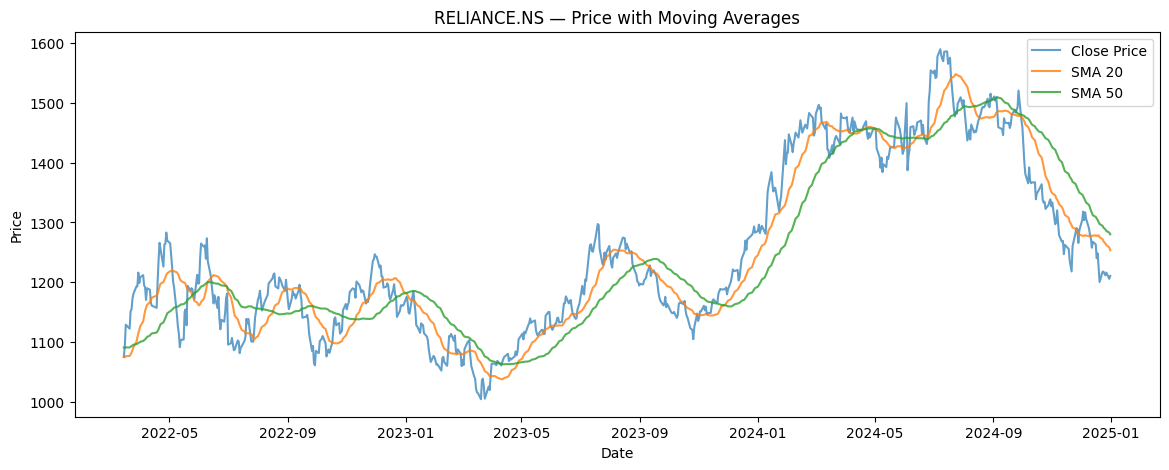

In [250]:
from src.utils import plot_price_with_sma
import matplotlib.pyplot as plt

fig = plot_price_with_sma(df, "RELIANCE.NS")
plt.show()

In [251]:
from src.sentiment import get_news_sentiment, interpret_sentiment

# Replace with your actual API key
API_KEY = "71d668f9bbe543da94b23c3aaeb74bd1"

score, headlines = get_news_sentiment("RELIANCE.NS", API_KEY)

print(f"Overall Sentiment Score: {score:.4f}")
print(f"Sentiment: {interpret_sentiment(score)}")
print(f"\nTop 5 Headlines:")
for h in headlines[:5]:
    print(f"  {h['sentiment']:.3f} — {h['headline']}")

Overall Sentiment Score: 0.0214
Sentiment: Neutral 😐

Top 5 Headlines:
  0.273 — Manufactured Savings: How Ember Turns Assumptions into Energy Policy
  0.586 — Alani Nu Energy Drink: 10 Must-Know Facts on Viral Zero-Sugar Boost as Sales Soar
  0.000 — LPG carrier Jag Vikram first India-flagged vessel to cross Hormuz after US–Iran ceasefire
  0.000 — The Way You Eat Carbs Could Shape Your Brain Health Decades Later
  0.318 — Indonesia considers EV incentives with industry, regulators


In [252]:
score, headlines = get_news_sentiment("RELIANCE.NS", API_KEY)

print(f"Overall Sentiment Score: {score:.4f}")
print(f"Sentiment: {interpret_sentiment(score)}")
print(f"\nTop 5 Headlines:")
for h in headlines[:5]:
    print(f"  {h['sentiment']:.3f} — {h['headline']}")

Overall Sentiment Score: 0.0214
Sentiment: Neutral 😐

Top 5 Headlines:
  0.273 — Manufactured Savings: How Ember Turns Assumptions into Energy Policy
  0.586 — Alani Nu Energy Drink: 10 Must-Know Facts on Viral Zero-Sugar Boost as Sales Soar
  0.000 — LPG carrier Jag Vikram first India-flagged vessel to cross Hormuz after US–Iran ceasefire
  0.000 — The Way You Eat Carbs Could Shape Your Brain Health Decades Later
  0.318 — Indonesia considers EV incentives with industry, regulators


In [253]:
import requests
from bs4 import BeautifulSoup

url = "https://www.moneycontrol.com/stocks/company_info/stock_news.php?sc_id=RI"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
print(f"Status code: {response.status_code}")
print(f"Page length: {len(response.text)}")
print(response.text[:2000])

Status code: 200
Page length: 516948
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "https://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">
<html xmlns="https://www.w3.org/1999/xhtml">
<head>
<meta http-equiv="Content-Type" content="text/html; charset=utf-8" />

<title>Reliance News: Latest News Updates on Reliance, Reliance Results News, News on Reliance for last 6 months,  Reliance Share/Stock News</title>
<meta name="description" content="Get latest Reliance News/Updates and Results/Analysis. Also get Reliance Share/Stock detailed Information on Reliance along with top stories and articles on Reliance during last 6 months." />

<meta name="keywords" content="Reliance Industries Results, Reliance Industries Q1/Q2/Q3/Q4 Results News, Reliance Industries Second Quarter Results News, Reliance Industries Quarterly Results News, Reliance Industries Results Analysis, Reliance Industries News article, Reliance Industries updates, Reliance Industries news today, Reliance 

In [254]:
soup = BeautifulSoup(response.text, 'html.parser')

# Try to find news headlines
headlines = soup.find_all('h2')
print(f"Found {len(headlines)} h2 tags")
for h in headlines[:10]:
    print(h.text.strip())

Found 0 h2 tags


In [255]:
# Try different tags
for tag in ['h1', 'h2', 'h3', 'h4', 'a', 'p']:
    elements = soup.find_all(tag)
    print(f"{tag}: {len(elements)} found")

h1: 1 found
h2: 0 found
h3: 0 found
h4: 0 found
a: 675 found
p: 110 found


In [256]:
# Print all anchor tag texts to find headlines
for a in soup.find_all('a')[:50]:
    text = a.text.strip()
    if len(text) > 30:  # only show meaningful text, not short links
        print(text)

HDFC Bank INE040A01034, HDFCBANK, 500180
Reliance INE002A01018, RELIANCE, 500325
Ola Electric INE0LXG01040, OLAELEC, 544225
Vedanta INE205A01025, VEDL, 500295
Adani Power INE814H01029, ADANIPOWER, 533096


In [258]:
import requests
from bs4 import BeautifulSoup

def scrape_yahoo_finance_news(ticker):
    """Scrape news headlines from Yahoo Finance for a given ticker."""
    
    url = f"https://finance.yahoo.com/quote/{ticker}/news"
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all anchor tags with meaningful text
    headlines = []
    for a in soup.find_all('a'):
        text = a.text.strip()
        if len(text) > 30:
            headlines.append(text)
    
    return headlines[:20]

headlines = scrape_yahoo_finance_news("RELIANCE.NS")
for h in headlines:
    print(h)

In [259]:
import yfinance as yf

ticker = yf.Ticker("RELIANCE.NS")
news = ticker.news

print(f"Found {len(news)} news articles")
for article in news[:5]:
    print(article)

Found 10 news articles
{'id': 'e3d64567-6fb7-3585-a3a8-78becf60edae', 'content': {'id': 'e3d64567-6fb7-3585-a3a8-78becf60edae', 'contentType': 'STORY', 'title': 'India permits Iranian oil tankers to berth for Reliance, sources say', 'description': '', 'summary': "By Nidhi Verma and Jonathan Saul NEW DELHI/LONDON, April 10 (Reuters) - India's shipping ministry has granted special permission to four vessels carrying Iranian oil - as requested by Reliance", 'pubDate': '2026-04-10T16:08:02Z', 'displayTime': '2026-04-10T16:08:02Z', 'isHosted': True, 'bypassModal': False, 'previewUrl': None, 'thumbnail': {'originalUrl': 'https://media.zenfs.com/en/reuters.com/288e0949c131b8a2465a5107d740bd26', 'originalWidth': 800, 'originalHeight': 562, 'caption': 'A bird flies past a Reliance Industries logo installed on its mart in Ahmedabad, India January 16, 2017. REUTERS/Amit Dave', 'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/qrgw1ZIK8.aDmNHlGYIyRA--~B/aD01NjI7dz04MDA7YXBwaWQ9eXRhY2h5b24

In [262]:
import importlib
import src.sentiment
importlib.reload(src.sentiment)

from src.sentiment import get_news_sentiment, interpret_sentiment

score, headlines = get_news_sentiment("RELIANCE.NS")

print(f"Overall Sentiment Score: {score:.4f}")
print(f"Sentiment: {interpret_sentiment(score)}")
print(f"\nTop 5 Headlines:")
for h in headlines[:5]:
    print(f"  {h['sentiment']:.3f} — {h['headline']}")

Overall Sentiment Score: -0.0979
Sentiment: Negative 😟

Top 5 Headlines:
  0.000 — India permits Iranian oil tankers to berth for Reliance, sources say
  0.000 — India's Reliance buys Venezuelan oil directly from PDVSA, document and data show
  0.000 — How The Investment Story For Reliance Industries (NSEI:RELIANCE) Is Quietly Shifting On New Assumptions
  -0.599 — India diesel exports to SE Asia hit 7-year high in March due to Iran war, data shows
  0.000 — OpenAI Appoints JioStar CEO to Lead Asia Expansion Targeting 1.4 Billion India Market
